In [2]:
from pandas.core.computation.check import NUMEXPR_INSTALLED

In [3]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv("powerplant_data.csv");

In [5]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [6]:
# AT -- Temperature value
# V -- vaccum
# AP -- pressure
# RH -- Humidity
# PE -- produced energy

In [7]:
df.isna().sum() #we don't have null values here

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [8]:
#defining X and y
X=df.drop("PE", axis = 1)
y = df["PE"]

In [9]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [10]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.2, random_state= 42) 

In [12]:
df.shape

(9568, 5)

In [13]:
from sklearn.preprocessing import StandardScaler

s = StandardScaler()
X_train_scaled = s.fit_transform(X_train)
X_test_scaled = s.transform(X_test)

In [14]:
#converting into Tensors
import torch
import torch.nn as nn

In [15]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

Y_train_tensor = torch.tensor(Y_train.values, dtype=torch.float32).view(-1,1)
Y_test_tensor = torch.tensor(Y_test.values, dtype=torch.float32).view(-1,1)

In [16]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor,Y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,Y_test_tensor)

In [17]:
# creating dataloader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [18]:
#Building our ANN Model
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        #defining model where self refers to the object of the ANN
        self.model = nn.Sequential(
          #1st hidden layer
          nn.Linear(X_train.shape[1], 6), #where 6 is no. of neurons
          nn.ReLU(),

          #2nd hidden layer
          nn.Linear(6, 6), 
          nn.ReLU(),

          #output layer
          nn.Linear(6, 1) 
        ) 
    

    def forward(self, x):
        return self.model(x)

In [19]:
import torch.optim as optim
model = ANN()

#loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())
#we have only defined the learning it till here

In [20]:
print("Hello World")

Hello World


In [21]:
#training the ANN model from here
train_losses = []
val_losses = []
epochs = 100

best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for one epoch i.e, loss for all the batches

    for xb, yb in train_loader: #xb = feature of one batch & yb = label of one batch
        optimizer.zero_grad() #so that every time we start with fresh gradients
        
        outputs = model(xb) #forward propagation....predicted outputs for this batch
        loss = criterion(outputs, yb) #compute loss
        loss.backward() #backward propagation....compute gradients
        optimizer.step() #params update

        running_loss += loss.item() # loss is a tensor => py float
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    #validation
    # at the time of validation we don't have to do backward prop
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradient compute ..it also saves memory
        for xb, yb in train_loader: 
            outputs = model(xb) 
            loss = criterion(outputs, yb) 
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> training loss = {epoch_train_loss} & validation loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss :
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch 1/100 ==> training loss = 206684.27220052082 & validation loss = 823129.875
epoch 2/100 ==> training loss = 201958.00110677083 & validation loss = 782700.5625
epoch 3/100 ==> training loss = 183433.27174479168 & validation loss = 671533.25
epoch 4/100 ==> training loss = 147024.39869791668 & validation loss = 495830.9375
epoch 5/100 ==> training loss = 99708.18323567709 & validation loss = 303889.21875
epoch 6/100 ==> training loss = 56084.16408691406 & validation loss = 156496.828125
epoch 7/100 ==> training loss = 28399.46926269531 & validation loss = 81944.015625
epoch 8/100 ==> training loss = 16628.369364420574 & validation loss = 55804.0703125
epoch 9/100 ==> training loss = 12566.679557291667 & validation loss = 45725.78515625
epoch 10/100 ==> training loss = 10489.10151570638 & validation loss = 38216.10546875
epoch 11/100 ==> training loss = 8658.902648925781 & validation loss = 31179.60546875
epoch 12/100 ==> training loss = 6935.462714640299 & validation loss = 24495.0

In [22]:
# %pip install matplotlib

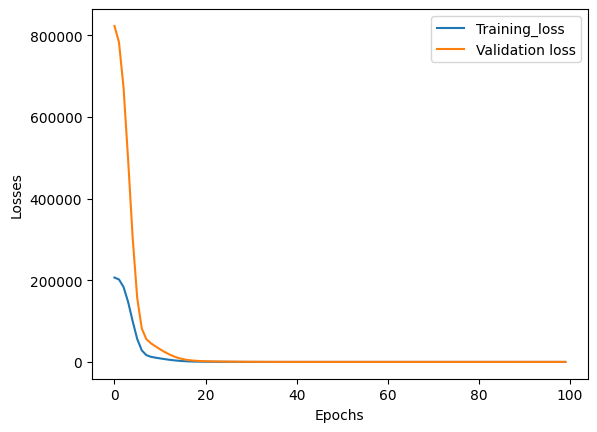

In [23]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss" : train_losses,
    "Validation Loss" : val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training_loss")
plt.plot(loss_df["Validation Loss"], label = "Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [24]:
# Loading the best model

model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [34]:
#model evaluation
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, Y_train_tensor)
    test_mse_loss = criterion(test_preds, Y_test_tensor)
    
print("Training MSE : ", train_mse_loss.item()) #we use .item to convert tensor to python float
print("Testing MSE : ", test_mse_loss.item())

Training MSE :  20.269132614135742
Testing MSE :  18.79345703125


In [35]:
from sklearn.metrics import r2_score

print("r2 score : ", r2_score(Y_test, test_preds))

r2 score :  0.9343217188831473


In [36]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns= ["Predicted Values"])
actual_df = pd.DataFrame(Y_test.values, columns= ["Actual Values"])

pd.concat([predicted_df, actual_df], axis = 1)

,Predicted Values,Actual Values
0,435.411133,433.27
1,437.186646,438.16
2,461.396515,458.42
3,476.619263,480.82
4,435.037781,441.41
...,...,...
1909,451.877045,456.70
1910,431.799805,438.04
1911,468.002197,467.80
1912,431.185669,437.14
